## Neural Networks Project 

## PART A

### 1. Data import and Understanding

**A. Read the ‘Signals.csv’ as DataFrame and import required libraries.**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import classification_report
import keras
import tensorflow as tf
from tensorflow.keras.layers import Dense,InputLayer
from tensorflow.keras.models import Sequential
from keras.initializers import HeNormal
from keras.layers import BatchNormalization, Dropout
from keras.optimizers import RMSprop

from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import GridSearchCV
from keras.utils import to_categorical


from scikeras.wrappers import KerasClassifier,KerasRegressor

from sklearn.metrics import classification_report

import h5py
%matplotlib inline

In [94]:
data=pd.read_csv("NN Project Data - Signal.csv")

**B. Check for missing values and print percentage for each attribute.**

In [95]:
data.head()

,Parameter 1,Parameter 2,Parameter 3,Parameter 4,Parameter 5,Parameter 6,Parameter 7,Parameter 8,Parameter 9,Parameter 10,Parameter 11,Signal_Strength
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [96]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Parameter 1,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
Parameter 2,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
Parameter 3,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
Parameter 4,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
Parameter 5,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
Parameter 6,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
Parameter 7,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
Parameter 8,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
Parameter 9,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
Parameter 10,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Parameter 1      1599 non-null   float64
 1   Parameter 2      1599 non-null   float64
 2   Parameter 3      1599 non-null   float64
 3   Parameter 4      1599 non-null   float64
 4   Parameter 5      1599 non-null   float64
 5   Parameter 6      1599 non-null   float64
 6   Parameter 7      1599 non-null   float64
 7   Parameter 8      1599 non-null   float64
 8   Parameter 9      1599 non-null   float64
 9   Parameter 10     1599 non-null   float64
 10  Parameter 11     1599 non-null   float64
 11  Signal_Strength  1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Understanding the data:
- 11 independent variables are present in the dataset
- Signal strength is the target variable and ,the value for the same ranges from 3 to 8
- The independent variables, parameter 2,3,5,8,9 and 10 have values almost in the same range, while rest of the parameters have a different range which suggests that the data will require normalization/standardization
- There are 1599 rows in the dataset and no null values in any of the columns

In [98]:
per=0
for i in data.columns:
    per=(data[i].isnull().sum()/data.shape[0])*100
    print("% of missing values in column ",i ," is ",per)

% of missing values in column  Parameter 1  is  0.0
% of missing values in column  Parameter 2  is  0.0
% of missing values in column  Parameter 3  is  0.0
% of missing values in column  Parameter 4  is  0.0
% of missing values in column  Parameter 5  is  0.0
% of missing values in column  Parameter 6  is  0.0
% of missing values in column  Parameter 7  is  0.0
% of missing values in column  Parameter 8  is  0.0
% of missing values in column  Parameter 9  is  0.0
% of missing values in column  Parameter 10  is  0.0
% of missing values in column  Parameter 11  is  0.0
% of missing values in column  Signal_Strength  is  0.0


In [99]:
data.isnull().sum()

Parameter 1        0
Parameter 2        0
Parameter 3        0
Parameter 4        0
Parameter 5        0
Parameter 6        0
Parameter 7        0
Parameter 8        0
Parameter 9        0
Parameter 10       0
Parameter 11       0
Signal_Strength    0
dtype: int64

**C. Check for presence of duplicate records in the dataset and impute with appropriate method.**

In [100]:
data.duplicated().sum()

240

In [101]:
data["Signal_Strength"].value_counts()

5    681
6    638
7    199
4     53
8     18
3     10
Name: Signal_Strength, dtype: int64

In [102]:
data[data.duplicated()].loc[:,"Signal_Strength"].value_counts()

5    104
6    103
7     32
8      1
Name: Signal_Strength, dtype: int64

- From the target variable counts, it is clear that the dataset is not balanced.
- 240 rows are duplicates which means that a row has its occurence for more than once in the dataframe.
- From the duplicate row count based on the target variable, we understand that deleting the duplicates might not have add more imbalance to the dataset

**Removing the duplicate rows from the dataset and copying the data set without duplicates into a new dataset**

In [103]:
data_dd=data.drop_duplicates(keep="first",inplace=False)

In [104]:
data_dd.duplicated().sum()

0

In [105]:
data.duplicated().sum()

240

**D. Visualise distribution of the target variable.**

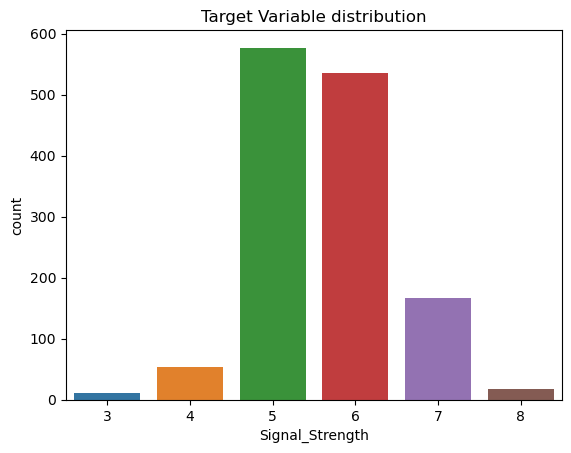

In [106]:
sns.countplot(data_dd,x="Signal_Strength")
plt.title("Target Variable distribution")
plt.show()

- The target variable is highly imbalanced with the maximum data points available for 5 and 6
- Classes 3 and 8 has the least number of datapoints


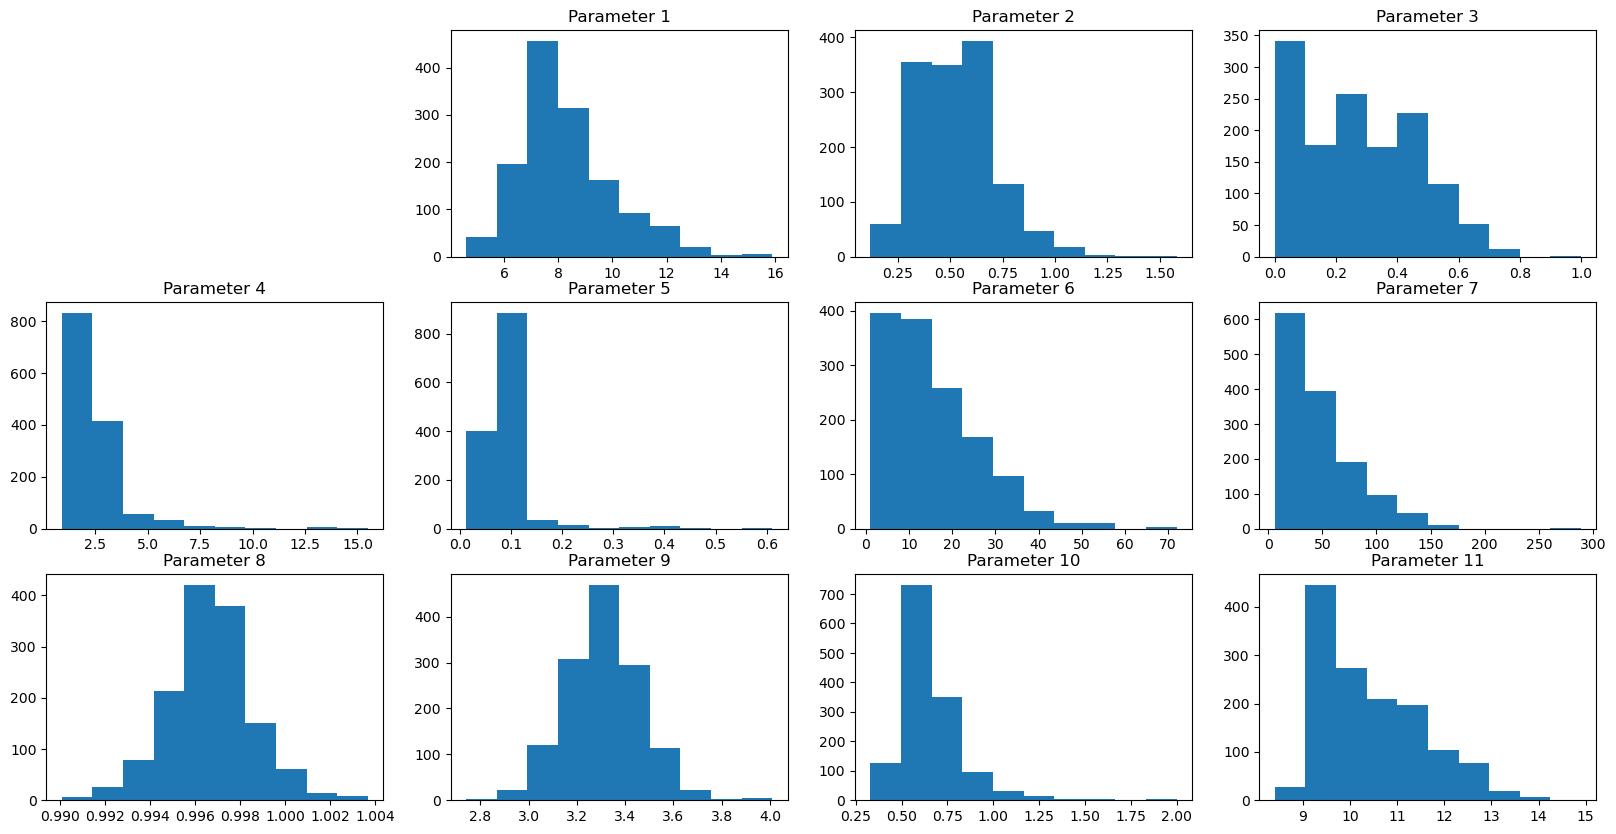

In [107]:
plt.figure(figsize=(20,10))
for i in range(1,12):
    plt.subplot(3,4,i+1)
    x1="Parameter "+str(i)
    plt.hist(data_dd[x1])
    plt.title(x1)
plt.show()

**E. Share insights from the initial data analysis (at least 2).**

Insights from the analysis
 - Dataset is imbalanced because not all the target variables are having a good representation.
 - Target variable "signal strenght" has values ranging from 3 to 8
 - Among the 11 independent variables parameter 6 and 7 are having the maximum standard deviation which means that  parameter 6 and 7 have the most dispersed data among the all the parameters
 - Parameter 9 is having almost a symmetric normal distribution, rest of the parameters are skewed distributions


### 2. Data preprocessing

**A. Split the data into X & Y.**

In [108]:
X=data_dd.drop("Signal_Strength",axis=1)
y=data_dd[["Signal_Strength"]]

**B. Split the data into train & test with 70:30 proportion.**

In [109]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,stratify=y,random_state=1)

**C. Print shape of all the 4 variables and verify if train and test data is in sync.**

In [110]:
print("Size of the training data",x_train.shape)
print("Shape of the target variable for the training data",y_train.shape)
print("Size of the testing data",x_test.shape)
print("Shape of the target variable for the testing data",y_test.shape)

Size of the training data (951, 11)
Shape of the target variable for the training data (951, 1)
Size of the testing data (408, 11)
Shape of the target variable for the testing data (408, 1)


In [111]:
y_train.value_counts()

Signal_Strength
5                  404
6                  374
7                  117
4                   37
8                   12
3                    7
dtype: int64

In [112]:
y_test.value_counts()

Signal_Strength
5                  173
6                  161
7                   50
4                   16
8                    5
3                    3
dtype: int64

- Training data has 951 data points and there are 11 independent variables for the dataset
- Testing set has 408 datapoints
- Target variables are the Signal strength whose values ranges from 3 to 8

**D. Normalise the train and test data with appropriate method**

-From the data distribution of the independent variables it was clear that the range of values for the independent variables are different and hence we use standard scaler to scale the independent variables to be in the same range

In [113]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

**E. Transform Labels into format acceptable by Neural Network**

In [114]:
ohe=OneHotEncoder()
y_train_cat=ohe.fit_transform(y_train).todense()
y_test_cat=ohe.fit_transform(y_test).todense()

In [115]:
y_test_cat.shape

(408, 6)

In [116]:
y_train_cat.shape

(951, 6)

In [117]:
y_test_cat[0:5]

matrix([[0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.]])

In [118]:
y_test

,Signal_Strength
441,6
1135,6
560,5
620,5
1094,6
...,...
373,5
1065,6
482,5
1052,5


### 3. Model Training & Evaluation using Neural Network

**A. Design a Neural Network to train a classifier.**

In [119]:
model0=Sequential()
model0.add(Dense(32,input_shape=(11,),activation="relu",kernel_initializer=HeNormal()))
model0.add(Dense(32,activation="relu",kernel_initializer=HeNormal()))
model0.add(Dense(64,activation="relu",kernel_initializer=HeNormal()))
model0.add(Dense(6,activation="softmax"))

model0.compile(optimizer="adam",loss = "categorical_crossentropy", metrics = ["accuracy"])           

**B. Train the classifier using previously designed Architecture**

In [120]:
history = model0.fit(x_train, y_train_cat, batch_size = 200, validation_data=(x_test, y_test_cat),epochs = 100, verbose = 1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.2330 - loss: 1.9761 - val_accuracy: 0.3235 - val_loss: 1.7636
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3417 - loss: 1.6655 - val_accuracy: 0.4118 - val_loss: 1.5115
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4370 - loss: 1.4316 - val_accuracy: 0.4828 - val_loss: 1.3764
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5009 - loss: 1.2865 - val_accuracy: 0.5270 - val_loss: 1.3023
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5136 - loss: 1.2043 - val_accuracy: 0.5294 - val_loss: 1.2587
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5386 - loss: 1.1911 - val_accuracy: 0.5564 - val_loss: 1.2298
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5497 - loss: 1.1505 - val_accuracy: 0.5686 - val_loss: 1.2054
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5534 - loss: 1.1323 - val_accuracy: 0.5809 - val_loss:

Epoch 52/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6580 - loss: 0.8270 - val_accuracy: 0.5784 - val_loss: 1.0524
Epoch 53/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6662 - loss: 0.7997 - val_accuracy: 0.5711 - val_loss: 1.0513
Epoch 54/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6835 - loss: 0.8037 - val_accuracy: 0.5711 - val_loss: 1.0504
Epoch 55/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6816 - loss: 0.7936 - val_accuracy: 0.5760 - val_loss: 1.0522
Epoch 56/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6805 - loss: 0.7841 - val_accuracy: 0.5833 - val_loss: 1.0525
Epoch 57/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6893 - loss: 0.7806 - val_accuracy: 0.5809 - val_loss: 1.0508
Epoch 58/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6898 - loss: 0.7913 - val_accuracy: 0.5760 - val_loss: 1.0500
Epoch 59/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6838 - loss: 0.7985 - val_accuracy: 0.5662 - v

**C. Plot 2 separate visuals.
 i. Training Loss and Validation Loss
 ii. Training Accuracy and Validation Accuracy**

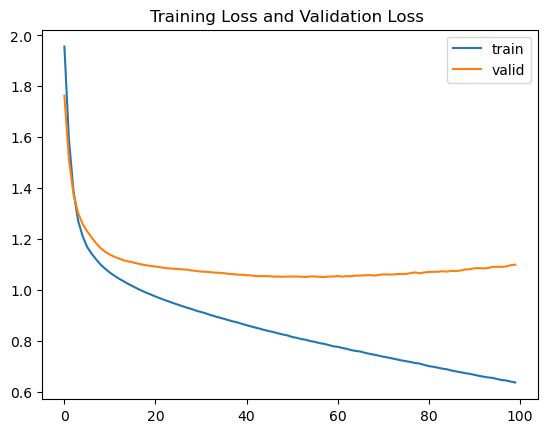

In [121]:
# Capturing learning history per epoch
hist  = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)
plt.title("Training Loss and Validation Loss ")
plt.show()


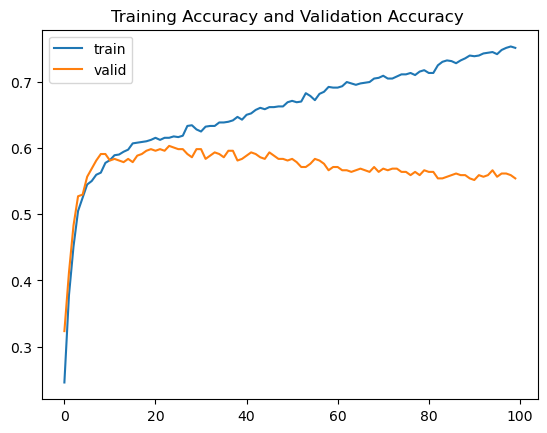

In [122]:
# Capturing learning history per epoch
hist  = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

# Plotting accuracy at different epochs
plt.plot(hist['accuracy'])
plt.plot(hist['val_accuracy'])
plt.legend(("train" , "valid") , loc =0)
plt.title("Training Accuracy and Validation Accuracy ")
plt.show()


In [123]:
#Printing results
results0 = model0.evaluate(x_test, y_test_cat)

y_pred0=model0.predict(x_test)

y_pred_final0=[]
for i in y_pred0:
  y_pred_final0.append(np.argmax(i)+3)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5367 - loss: 1.2005 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [124]:
print(classification_report(y_test,y_pred_final0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.40      0.12      0.19        16
           5       0.64      0.68      0.66       173
           6       0.50      0.56      0.53       161
           7       0.41      0.32      0.36        50
           8       0.00      0.00      0.00         5

    accuracy                           0.55       408
   macro avg       0.33      0.28      0.29       408
weighted avg       0.54      0.55      0.54       408



**D. Design new architecture/update existing architecture in attempt to improve the performance of the model.**

In [125]:
#Adding dropouts and including Batch Normalization after every layer

model1=Sequential()
model1.add(Dense(256,input_shape=(11,),activation="relu",kernel_initializer=HeNormal()))
model1.add(BatchNormalization())
model1.add(Dropout(0.4))

model1.add(Dense(64,activation="relu",kernel_initializer=HeNormal()))
model1.add(BatchNormalization())
model1.add(Dropout(0.6))

model1.add(Dense(64,activation="relu",kernel_initializer=HeNormal()))
model1.add(BatchNormalization())
model1.add(Dropout(0.6))

model1.add(Dense(32,activation="relu",kernel_initializer=HeNormal()))
model1.add(BatchNormalization())
model1.add(Dropout(0.6))

model1.add(Dense(6,activation="softmax"))

model1.compile(optimizer="adam",loss = "categorical_crossentropy", metrics = ["accuracy"])


In [126]:
history1 = model1.fit(x_train, y_train_cat, validation_data=(x_test, y_test_cat),epochs = 50, verbose = 1)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.2028 - loss: 2.8376 - val_accuracy: 0.2451 - val_loss: 1.8360
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1956 - loss: 2.6668 - val_accuracy: 0.4632 - val_loss: 1.5830
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2445 - loss: 2.3708 - val_accuracy: 0.5343 - val_loss: 1.4502
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2384 - loss: 2.3604 - val_accuracy: 0.5417 - val_loss: 1.3611
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2866 - loss: 2.0763 - val_accuracy: 0.5613 - val_loss: 1.2963
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3523 - loss: 1.9694 - val_accuracy: 0.5711 - val_loss: 1.2307
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3646 - loss: 1.7732 - val_accuracy: 0.5588 - val_loss: 1.1879
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4517 - loss: 1.6155 - val_accuracy: 0.5809 - val_los

**E. Plot visuals as in Q3.C and share insights about difference observed in both the models.**

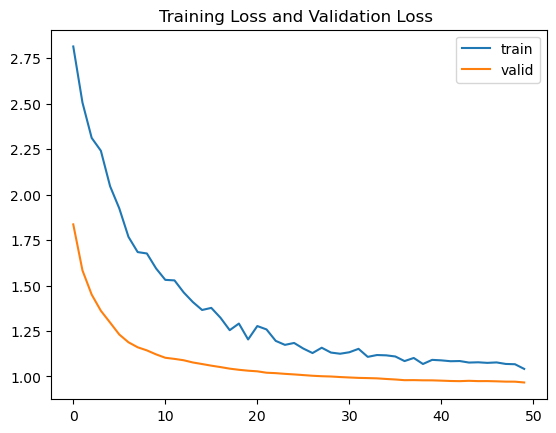

In [127]:
# Capturing learning history per epoch
hist  = pd.DataFrame(history1.history)
hist['epoch'] = history1.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)
plt.title("Training Loss and Validation Loss ")
plt.show()


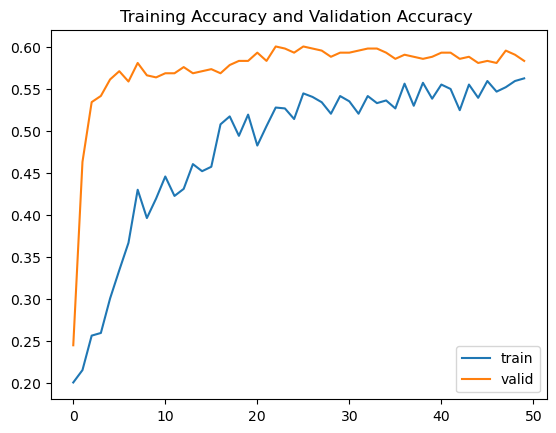

In [128]:
# Capturing learning history per epoch
hist  = pd.DataFrame(history1.history)
hist['epoch'] = history1.epoch

# Plotting accuracy at different epochs
plt.plot(hist['accuracy'])
plt.plot(hist['val_accuracy'])
plt.legend(("train" , "valid") , loc =0)
plt.title("Training Accuracy and Validation Accuracy ")
plt.show()



In [129]:
#Printing results
results1 = model1.evaluate(x_test, y_test_cat)

y_pred1=model1.predict(x_test)



13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5395 - loss: 1.0129 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [130]:
y_pred_final1=[]
for i in y_pred1:
  y_pred_final1.append(np.argmax(i)+3)


In [131]:
print(classification_report(y_test,y_pred_final1))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.64      0.75      0.69       173
           6       0.53      0.63      0.58       161
           7       0.43      0.12      0.19        50
           8       0.00      0.00      0.00         5

    accuracy                           0.58       408
   macro avg       0.27      0.25      0.24       408
weighted avg       0.54      0.58      0.55       408



Insights from the neural network models that are built:
- The testing accuracy has improved from 55% to 58%
- Since the data is highly imbalanced the model is unable to predict the Signal Strengths that are not having a good representation in the training data
- Balancing the target data might have a significant impact to improve the overall accuracy of the model
- Model0 was an overfit model because the training accuracy was almost 74% while the testing accuracy was only 55% while the overfitting is reduced in Model 1 with the inclusion of dropouts so some of the created features in the layers are getting dropped.
- Insample accuracy for Model 1 is 54% and out of sample accuracy for model 1 is 58% which means the inclusion of dropouts have reduced the overfitting to a large extend.

## PART B

### DOMAIN: Autonomous Vehicles

### 1. Data Import and Exploration

**A. Read the .h5 file and assign to a variable.**

In [8]:
vehicles= h5py.File('Autonomous_Vehicles_SVHN_single_grey1.h5', 'r')

**B. Print all the keys from the .h5 file.**

In [9]:
vehicles.keys()

<KeysViewHDF5 ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']>

**C. Split the data into X_train, X_test, Y_train, Y_test**

In [10]:
X_test = vehicles.get('X_test')
X_train = vehicles.get('X_train')
X_val = vehicles.get('X_val')
y_test = vehicles.get('y_test')
y_train = vehicles.get('y_train')
y_val = vehicles.get('y_val')

In [11]:
X_test = np.array(X_test)
X_train = np.array(X_train)
X_val = np.array(X_val)
y_test = np.array(y_test)
y_train = np.array(y_train)
y_val = np.array(y_val)

### 2. Data Visualisation and preprocessing

**A. Print shape of all the 4 data split into x, y, train, test to verify if x & y is in sync.**

In [12]:
print("Shape of the Testing data X_test",X_test.shape)
print("Shape of the target testing data Y_test",y_test.shape)
print("Shape of the Training data X_train",X_train.shape)
print("Shape of the target training data Y_train",y_train.shape)
print("Shape of the Validation data X_train",X_val.shape)
print("Shape of the target validation data Y_train",y_val.shape)

Shape of the Testing data X_test (18000, 32, 32)
Shape of the target testing data Y_test (18000,)
Shape of the Training data X_train (42000, 32, 32)
Shape of the target training data Y_train (42000,)
Shape of the Validation data X_train (60000, 32, 32)
Shape of the target validation data Y_train (60000,)


**B. Visualise first 10 images in train data and print its corresponding labels.**

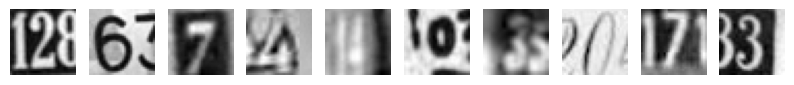

The above images are represents  [2 6 7 4 4 0 3 0 7 3]


In [13]:
plt.figure(figsize=(10, 1))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(X_train[i],cmap="gray")
    plt.axis("off")
plt.show()
print("The above images are represents ",y_train[0:10])

**C. Reshape all the images with appropriate shape update the data in same variable.**

In [14]:
# Flatten the images
image_vector_size = 32*32
X_train = X_train.reshape(X_train.shape[0], image_vector_size)
X_test = X_test.reshape(X_test.shape[0], image_vector_size)
X_val= X_val.reshape(X_val.shape[0], image_vector_size)

**D. Normalise the images i.e. Normalise the pixel values**

In [15]:
X_train = X_train / 255.0
X_test = X_test / 255.0
X_val= X_val / 255.0

**E. Transform Labels into format acceptable by Neural Network**

In [16]:
y_train_cat=to_categorical(y_train)
y_test_cat=to_categorical(y_test)
y_val_cat=to_categorical(y_val)

**F. Print total Number of classes in the Dataset**

In [17]:
print("The total number of classes in the dataset are ",y_train_cat.shape[1])

The total number of classes in the dataset are  10


### 3. Model Training & Evaluation using Neural Network

**A. Design a Neural Network to train a classifier**

In [194]:
vehicle3=Sequential()
vehicle3.add(Dense(256,input_shape=(X_train.shape[1],),activation="relu",kernel_initializer=HeNormal()))
vehicle3.add(BatchNormalization())
vehicle3.add(Dropout(0.1))
vehicle3.add(Dense(128,activation="relu",kernel_initializer=HeNormal()))
vehicle3.add(BatchNormalization())

vehicle3.add(Dense(64,activation="relu",kernel_initializer=HeNormal()))
vehicle3.add(BatchNormalization())
vehicle3.add(Dropout(0.1))
vehicle3.add(Dense(32,activation="relu",kernel_initializer=HeNormal()))
vehicle3.add(BatchNormalization())
vehicle3.add(Dropout(0.1))
vehicle3.add(Dense(y_train_cat.shape[1],activation="softmax"))

vehicle3.compile(optimizer="adam",loss = "categorical_crossentropy", metrics = ["accuracy"])



**B. Train the classifier using previously designed Architecture (Use best suitable parameters).**

In [200]:
vehicle3_history = vehicle3.fit(X_train, y_train_cat,validation_data=(X_val, y_val_cat), batch_size=100,epochs = 65, verbose = 1)

Epoch 1/65
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8050 - loss: 0.6226 - val_accuracy: 0.7900 - val_loss: 0.6608
Epoch 2/65
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8074 - loss: 0.6140 - val_accuracy: 0.8121 - val_loss: 0.5972
Epoch 3/65
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8013 - loss: 0.6249 - val_accuracy: 0.8450 - val_loss: 0.4978
Epoch 4/65
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8088 - loss: 0.6098 - val_accuracy: 0.7873 - val_loss: 0.6966
Epoch 5/65
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8093 - loss: 0.6091 - val_accuracy: 0.7836 - val_loss: 0.6940
Epoch 6/65
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8103 - loss: 0.6050 - val_accuracy: 0.8148 - val_loss: 0.5924
Epoch 7/65
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8108 - loss: 0.6113 - val_accuracy: 0.8167 - val_loss: 0.5744
Epoch 8/65
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8100 - loss: 0.6042 - val_accuracy

**C. Evaluate performance of the model with appropriate metrics.**

In [201]:
#Printing results
results3 = vehicle3.evaluate(X_test, y_test_cat)

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8380 - loss: 0.5366


Testing accuracy for the model is 83.8%

In [202]:
# predicting the model on test data
y_pred=vehicle3.predict(X_test)

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [203]:
# As our outputs are probabilities so we will try to get the output class from these probablities by getting the maximum value
y_pred_final=[]
for i in y_pred:
  y_pred_final.append(np.argmax(i))

In [204]:
print(classification_report(y_test,y_pred_final))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1814
           1       0.83      0.85      0.84      1828
           2       0.88      0.83      0.85      1803
           3       0.69      0.81      0.75      1719
           4       0.84      0.88      0.86      1812
           5       0.84      0.82      0.83      1768
           6       0.86      0.82      0.84      1832
           7       0.89      0.83      0.86      1808
           8       0.86      0.79      0.82      1812
           9       0.86      0.81      0.84      1804

    accuracy                           0.83     18000
   macro avg       0.84      0.83      0.83     18000
weighted avg       0.84      0.83      0.83     18000



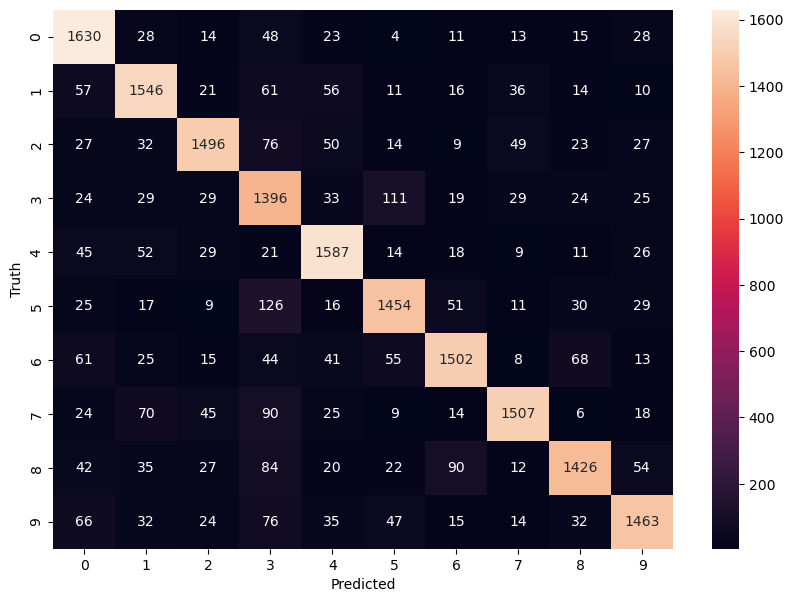

In [205]:
cm=confusion_matrix(y_test,y_pred_final)

plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

**D. Plot the training loss, validation loss vs number of epochs and training accuracy, validation accuracy vs number of epochs plot and write your observations on the same.**

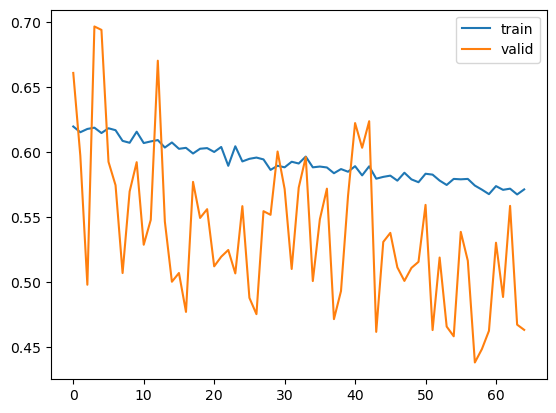

In [206]:
# Capturing learning history per epoch
hist  = pd.DataFrame(vehicle3_history.history)
hist['epoch'] = vehicle3_history.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)


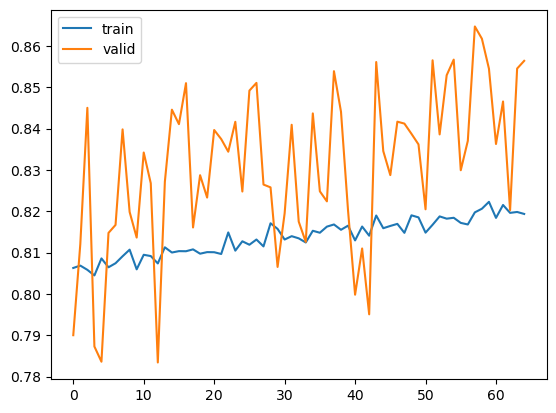

In [209]:
# Capturing learning history per epoch
hist  = pd.DataFrame(vehicle3_history.history)
hist['epoch'] = vehicle3_history.epoch

# Plotting accuracy at different epochs
plt.plot(hist['accuracy'])
plt.plot(hist['val_accuracy'])
plt.legend(("train" , "valid") , loc =0)


Insights:
- Validation accuracy is oscillating around the training accuracy which shows that it is neither an overfitting nor an underfitting model
- validation loss is slightly less than the training loss
- Training accuracy is 83%, validation accuracy is 85% and the testing accuracy is 83% which shows that the model is a right fit because the accuracies are within the same range

**Hyperparameter tuning**

Inorder to understand if there are better parameters than the one that has been used in the model, let us perform hyperparameter tuning for the parameters like
- no of neurons in the hidden layer
- learning rate

In [1]:
def create_model(learn_rate,hidden_unit1,hidden_unit2,hidden_unit3,hidden_unit4):
  # create model
  model=Sequential()
  model.add(Dense(hidden_unit1,input_shape=(X_train.shape[1],),activation="relu",kernel_initializer=HeNormal()))
  model.add(BatchNormalization())
  model.add(Dropout(0.1))
  model.add(Dense(hidden_unit2,activation="relu",kernel_initializer=HeNormal()))
  model.add(BatchNormalization())

  model.add(Dense(hidden_unit3,activation="relu",kernel_initializer=HeNormal()))
  model.add(BatchNormalization())
  model.add(Dropout(0.1))
  model.add(Dense(hidden_unit4,activation="relu",kernel_initializer=HeNormal()))
  model.add(BatchNormalization())
  model.add(Dropout(0.1))
  model.add(Dense(y_train_cat.shape[1],activation="softmax"))

	# Compile model
  optimizer = Adam(learning_rate=learn_rate)
  model.compile(loss="categorical_crossentropy", optimizer= optimizer, metrics=["accuracy"])
  return model

In [2]:
hidden_unit1=[256,128]
hidden_unit2=[128,64]
hidden_unit3=[64,32]
hidden_unit4=[32,16]
learn_rate = [0.001, 0.01]
hyperparameters = dict(learn_rate = learn_rate,
                       hidden_unit1=hidden_unit1,
                       hidden_unit2=hidden_unit2,
                       hidden_unit3=hidden_unit3,
                       hidden_unit4=hidden_unit4)

In [3]:
pip install scikeras[tensorflow]

Note: you may need to restart the kernel to use updated packages.


In [18]:
# Wrap model so it can be used by scikit-learn
neural_network = KerasClassifier(model=create_model,hidden_unit1=hidden_unit1,hidden_unit2=hidden_unit2,hidden_unit3=hidden_unit3,hidden_unit4=hidden_unit4,learn_rate=learn_rate)
#neural_network = KerasClassifier(model=create_model,verbose=1)

In [19]:
# Conduct Grid Search

# Create grid search
grid = GridSearchCV(estimator=neural_network, param_grid=hyperparameters, n_jobs=-1, cv=5)

# Fit grid search
grid_result = grid.fit(X_train, y_train_cat)

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.2126 - loss: 2.1379


In [22]:
print("\nBest: %f using %s" % (grid_result.best_score_, grid_result.best_params_))


Best: 0.344667 using {'hidden_unit1': 256, 'hidden_unit2': 128, 'hidden_unit3': 64, 'hidden_unit4': 32, 'learn_rate': 0.01}


From the above we understand that the hyper parameter tuning is not giving us a performance which is anywhere close the model performance that we have already achieved. Hence, we can confirm that the best parameters are for the model vehicle3. 